In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
# import stargazer
from stargazer.stargazer import Stargazer

In [15]:
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

In [16]:
from package_files.benefits_defns import *

# Read in data

In [64]:
df = pd.read_csv('../exports/occ_year_coeff_analysis.csv')

In [20]:
df

,Benefit,Occupation,Year,AI Coefficient,Error,P-Value,SOC_2021_2_NAME,YEAR,AI Demand,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,DURATION_CALC_ai,DURATION_CALC_non_ai,job_count,Prevalence: Tuition Assistance,Prevalence: Paid Leave,Prevalence: Health and Wellbeing,Prevalence: Parental Leave,Prevalence: Workplace Culture,Prevalence: Remote Work
0,EDU_ASSISTANCE,Architecture and Engineering Occupations,2019,-0.378773,0.202133,0.061,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61 days 12:15:02.088167053,59 days 00:38:58.224681261,42432,4.645079,11.566742,3.113216,0.782428,5.568910,2.348773
1,EDU_ASSISTANCE,Architecture and Engineering Occupations,2021,-0.191725,0.140017,0.171,Architecture and Engineering Occupations,2021,2.278018,15.179062,-2.642404,11.521036,107050.060606,11.095518,73216.702324,103.835046,146.209891,61 days 10:05:07.820646507,63 days 20:12:09.818420477,42098,7.187990,20.221863,3.722267,2.598698,10.442301,8.357362
2,EDU_ASSISTANCE,Architecture and Engineering Occupations,2022,-0.309976,0.108110,0.004,Architecture and Engineering Occupations,2022,2.446456,7.394079,15.179062,11.600475,115932.657459,11.235284,83342.705232,103.250399,139.103545,54 days 03:35:25.984251969,55 days 00:21:39.737909740,57103,8.840166,22.760626,4.591703,3.991034,15.806525,14.685004
3,EDU_ASSISTANCE,Architecture and Engineering Occupations,2020,-0.152420,0.196615,0.438,Architecture and Engineering Occupations,2020,1.977806,-2.642404,24.871731,11.428493,100957.585366,11.075966,72630.480348,103.182813,139.001677,60 days 03:48:03.257918552,59 days 07:22:44.995891537,33522,5.271165,16.428017,2.890639,1.312571,6.691128,4.442167
4,EDU_ASSISTANCE,Architecture and Engineering Occupations,2018,0.043941,0.219785,0.842,Architecture and Engineering Occupations,2018,1.626858,NaN,NaN,11.279748,85233.255814,11.095357,72599.869117,101.661881,117.401390,64 days 00:00:00,61 days 15:53:49.797789972,40569,3.307944,8.255072,1.466637,0.276073,4.777047,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,wfh_wham,Transportation and Material Moving Occupations,2019,-18.205488,17234.764550,0.999,Transportation and Material Moving Occupations,2019,0.033652,-18.600785,NaN,10.485831,38192.625000,10.591160,44183.609987,99.005500,86.440707,59 days 19:21:17.419354839,61 days 05:09:35.873339921,92120,4.829570,21.079027,3.222970,0.578593,2.248155,0.385060
611,wfh_wham,Transportation and Material Moving Occupations,2021,0.533101,0.527071,0.312,Transportation and Material Moving Occupations,2021,0.067199,149.616383,-20.001353,10.663532,48247.636364,10.664556,46919.891740,99.990403,102.829812,66 days 00:38:13.805309735,65 days 11:37:08.759134512,168157,7.579227,36.863764,7.994910,3.968315,5.318839,0.769559
612,wfh_wham,Transportation and Material Moving Occupations,2022,1.883420,0.299236,0.000,Transportation and Material Moving Occupations,2022,0.085570,27.338156,149.616383,10.630348,47164.969697,10.708293,48730.623684,99.272107,96.787125,56 days 16:49:13.846153846,57 days 22:00:26.193700453,136730,8.390990,36.712499,5.294376,6.326337,9.225481,0.806475
613,wfh_wham,Transportation and Material Moving Occupations,2020,-11.442227,437.577258,0.979,Transportation and Material Moving Occupations,2020,0.026921,-20.001353,-18.600785,10.529685,40678.900000,10.562795,42269.527535,99.686540,96.236940,55 days 05:03:09.473684211,62 days 12:28:49.640862836,141154,5.673945,29.072502,7.670346,1.370135,2.021905,0.565415


In [39]:
df['DURATION_CALC_ai'] = pd.to_timedelta(df['DURATION_CALC_ai']).dt.total_seconds() / (24 * 3600)

In [41]:
df['DURATION_CALC_non_ai'] = pd.to_timedelta(df['DURATION_CALC_non_ai']).dt.total_seconds() / (24 * 3600)

In [40]:
df['DURATION_CALC_ai']

0      61.510441
1      61.420229
2      54.149606
3      60.158371
4      64.000000
         ...    
610    59.806452
611    66.026549
612    56.700855
613    55.210526
614    48.523810
Name: DURATION_CALC_ai, Length: 615, dtype: float64

In [19]:
pd.set_option('display.max_columns', None)

In [25]:
# show rows in df with nas in ai coefficient
df[df['AI Coefficient'].isna()]

,Benefit,Occupation,Year,AI Coefficient,Error,P-Value,SOC_2021_2_NAME,YEAR,AI Demand,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,DURATION_CALC_ai,DURATION_CALC_non_ai,job_count,Prevalence: Tuition Assistance,Prevalence: Paid Leave,Prevalence: Health and Wellbeing,Prevalence: Parental Leave,Prevalence: Workplace Culture,Prevalence: Remote Work
69,EDU_ASSISTANCE,Personal Care and Service Occupations,2020,NaN,NaN,NaN,Personal Care and Service Occupations,2020,0.056786,-8.166525,20.950725,9.981969,21840.000000,10.415643,36208.732742,95.836320,60.316941,61 days 06:51:25.714285714,61 days 15:01:06.623376623,24654,3.309808,13.969336,2.052405,1.216841,3.581569,2.163225
85,EDU_ASSISTANCE,Transportation and Material Moving Occupations,2021,NaN,NaN,NaN,Transportation and Material Moving Occupations,2021,0.067199,149.616383,-20.001353,10.663532,48247.636364,10.664556,46919.891740,99.990403,102.829812,66 days 00:38:13.805309735,65 days 11:37:08.759134512,168157,7.579227,36.863764,7.994910,3.968315,5.318839,0.769559
246,PAID_LEAVE,Personal Care and Service Occupations,2019,NaN,NaN,NaN,Personal Care and Service Occupations,2019,0.061836,20.950725,NaN,10.349295,32576.666667,10.409556,36016.100200,99.421094,90.450289,61 days 06:00:00,62 days 11:26:36.952705054,25875,2.291787,9.236715,1.913043,0.668599,3.934300,0.896897
312,HEALTH_WELLBEING,Legal Occupations,2019,NaN,NaN,NaN,Legal Occupations,2019,0.621586,18.425080,NaN,10.998488,59993.000000,10.970941,66254.299484,100.251088,90.549595,59 days 12:43:38.181818182,58 days 11:02:24.655041698,10618,3.070258,15.709173,2.552270,1.742324,4.699567,6.572363
355,HEALTH_WELLBEING,Transportation and Material Moving Occupations,2021,NaN,NaN,NaN,Transportation and Material Moving Occupations,2021,0.067199,149.616383,-20.001353,10.663532,48247.636364,10.664556,46919.891740,99.990403,102.829812,66 days 00:38:13.805309735,65 days 11:37:08.759134512,168157,7.579227,36.863764,7.994910,3.968315,5.318839,0.769559
370,PARENTAL_LEAVE,"Arts, Design, Entertainment, Sports, and Media...",2018,NaN,NaN,NaN,"Arts, Design, Entertainment, Sports, and Media...",2018,0.574047,NaN,NaN,11.089872,71530.230769,10.667753,49168.466355,103.956965,145.479890,54 days 10:35:29.577464789,62 days 00:43:24.271928873,37105,2.280016,7.174235,1.234335,0.565961,4.061447,0.000000
379,PARENTAL_LEAVE,Community and Social Service Occupations,2021,NaN,NaN,NaN,Community and Social Service Occupations,2021,0.172751,13.802518,-27.591887,11.172405,83638.384615,10.836224,55792.444588,103.102384,149.909876,65 days 11:17:38.823529412,67 days 10:42:57.121771218,39363,9.646114,32.149480,5.350202,4.605848,10.824886,11.355638
396,PARENTAL_LEAVE,Healthcare Practitioners and Technical Occupat...,2019,NaN,NaN,NaN,Healthcare Practitioners and Technical Occupat...,2019,0.106339,-5.536856,NaN,11.253337,91906.684211,11.233370,88682.905383,100.177751,103.635175,65 days 15:29:31.428571429,61 days 05:53:29.228134997,177733,6.353350,12.532844,2.360845,0.604277,5.617415,2.342435
426,PARENTAL_LEAVE,Personal Care and Service Occupations,2019,NaN,NaN,NaN,Personal Care and Service Occupations,2019,0.061836,20.950725,NaN,10.349295,32576.666667,10.409556,36016.100200,99.421094,90.450289,61 days 06:00:00,62 days 11:26:36.952705054,25875,2.291787,9.236715,1.913043,0.668599,3.934300,0.896897


## Add dfs to dict

In [85]:
# create dict of benefit dfs
df_dict = {}
for benefit in benefits4:
    benefit_df = df[df['Benefit'] == benefit]
    df_dict[benefit] = benefit_df

(array([47., 12.,  5., 11.,  9.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         1.,  0.,  1.,  1.,  0.,  2.,  1.]),
 array([0.02692095, 0.51298152, 0.99904208, 1.48510265, 1.97116321,
        2.45722378, 2.94328435, 3.42934491, 3.91540548, 4.40146604,
        4.88752661, 5.37358717, 5.85964774, 6.3457083 , 6.83176887,
        7.31782944, 7.80389   , 8.28995057, 8.77601113, 9.2620717 ,
        9.74813226]),
 <BarContainer object of 20 artists>)

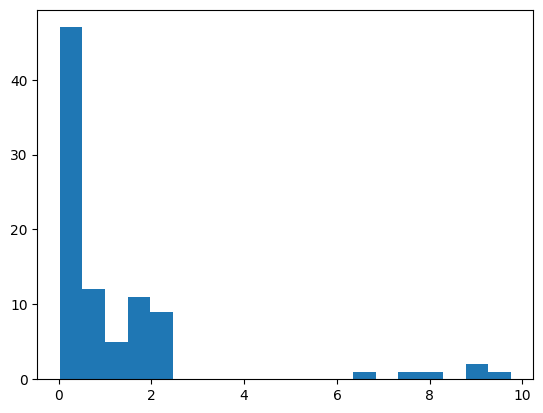

In [24]:
plt.hist(df_dict['EDU_ASSISTANCE']['AI Demand'], bins=20)

# Run Models

## Baseline with Demand (1)

In [86]:
import statsmodels.api as sm
benefit_models = {}
for benefit in df_dict.keys():
    benefit_df = df_dict[benefit]
    # drop nas in AI Coefficient
    benefit_df = benefit_df.dropna(subset=['AI Coefficient'])
    # Define the dependent and independent variables
    X = benefit_df['AI Demand']
    y = benefit_df['AI Coefficient']

    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    benefit_models[benefit] = []
    benefit_models[benefit].append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                            OLS Regression Results                            
Dep. Variable:         AI Coefficient   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     2.468
Date:                Thu, 24 Oct 2024   Prob (F-statistic):              0.120
Time:                        23:24:31   Log-Likelihood:                -290.12
No. Observations:                  88   AIC:                             584.2
Df Residuals:                      86   BIC:                             589.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.7522      0.834     

## + Prevalence (2)

In [87]:
import statsmodels.api as sm
for benefit in benefits4:
    benefit_df = df_dict[benefit]
    # drop nas in AI Coefficient
    benefit_df = benefit_df.dropna(subset=['AI Coefficient'])
    # Define the dependent and independent variables
    # X is AI ROLE % and Percent_with_{benefit}
    # benefit_df.rename(columns={f'{benefit}_prevalence}': f'Prevalence: {label}', inplace=True)
    label = benefits_labels_map[benefit]
    X = benefit_df[['AI Demand', f'Prevalence: {label}']]
    y = benefit_df['AI Coefficient']

    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    benefit_models[benefit].append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                            OLS Regression Results                            
Dep. Variable:         AI Coefficient   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     3.553
Date:                Thu, 24 Oct 2024   Prob (F-statistic):             0.0330
Time:                        23:24:33   Log-Likelihood:                -287.83
No. Observations:                  88   AIC:                             581.7
Df Residuals:                      85   BIC:                             589.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [88]:
from IPython.core.display import HTML

## + Salary (3)

In [89]:
import statsmodels.api as sm
for benefit in benefits4:
    benefit_df = df_dict[benefit]
    # drop nas in AI Coefficient
    benefit_df = benefit_df.dropna(subset=['AI Coefficient'])
    # Define the dependent and independent variables
    # X is AI ROLE % and Percent_with_{benefit}
    label = benefits_labels_map[benefit]
    # benefit_df.rename(columns={f'{benefit}_prevalence}': f'Prevalence: {label}', inplace=True)
    X = benefit_df[['AI Demand', f'Prevalence: {label}', 'Salary (Log) Premium']]
    y = benefit_df['AI Coefficient']

    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    benefit_models[benefit].append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                            OLS Regression Results                            
Dep. Variable:         AI Coefficient   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     2.345
Date:                Thu, 24 Oct 2024   Prob (F-statistic):             0.0787
Time:                        23:24:34   Log-Likelihood:                -287.83
No. Observations:                  88   AIC:                             583.7
Df Residuals:                      84   BIC:                             593.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [90]:
import numpy as np

## % Change Model (4)

In [91]:
import statsmodels.api as sm
for benefit in benefits4:
    benefit_df = df_dict[benefit]
    # drop nas in AI Coefficient
    benefit_df = benefit_df.replace([np.inf, -np.inf], np.nan)  # Replace inf with NaN

    benefit_df = benefit_df.dropna(subset=['AI Coefficient', 'AI Demand % Change'])
    
    # Define the dependent and independent variables
    # X is AI ROLE % and Percent_with_{benefit}
    label = benefits_labels_map[benefit]
    # benefit_df.rename(columns={f'{benefit}_prevalence}': f'Prevalence: {label}', inplace=True)
    X = benefit_df['AI Demand % Change']
    print(len(X))
    y = benefit_df['AI Coefficient']
    print(len(y))

    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    benefit_models[benefit].append(model)
    # Print the summary of the regression
    print(model.summary())

73
73
EDU_ASSISTANCE
                            OLS Regression Results                            
Dep. Variable:         AI Coefficient   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.5457
Date:                Thu, 24 Oct 2024   Prob (F-statistic):              0.462
Time:                        23:24:34   Log-Likelihood:                -245.20
No. Observations:                  73   AIC:                             494.4
Df Residuals:                      71   BIC:                             499.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const          

## Duration Model (5)

In [92]:
import statsmodels.api as sm
for benefit in benefits4:
    benefit_df = df_dict[benefit]
    # drop nas in AI Coefficient
    benefit_df = benefit_df.replace([np.inf, -np.inf], np.nan)  # Replace inf with NaN

    benefit_df = benefit_df.dropna(subset=['AI Coefficient', 'DURATION_CALC_ai'])
    benefit_df.rename(columns={'DURATION_CALC_ai': 'Avg AI Posting Duration'}, inplace=True)
    # Define the dependent and independent variables
    # X is AI ROLE % and Percent_with_{benefit}
    label = benefits_labels_map[benefit]
    # benefit_df.rename(columns={f'{benefit}_prevalence}': f'Prevalence: {label}', inplace=True)
    X = benefit_df['Avg AI Posting Duration']
    print(len(X))
    print(X.dtypes)
    y = benefit_df['AI Coefficient']
    print(len(y))

    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    benefit_models[benefit].append(model)
    # Print the summary of the regression
    print(model.summary())

88
float64
88
EDU_ASSISTANCE
                            OLS Regression Results                            
Dep. Variable:         AI Coefficient   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.433
Date:                Thu, 24 Oct 2024   Prob (F-statistic):              0.235
Time:                        23:24:35   Log-Likelihood:                -290.64
No. Observations:                  88   AIC:                             585.3
Df Residuals:                      86   BIC:                             590.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

# Display Models

In [93]:
for benefit in benefits4:
    stargazer = Stargazer(benefit_models[benefit])
    stargazer.title(f'Coefficients for {benefits_labels_map[benefit]}')
    display(HTML(stargazer.render_html()))
    # export to latex
    with open(f'../exports/occ_year_coeff_{benefit}.tex', 'w') as f:
        f.write(stargazer.render_latex())

# Testing Assumptions

## Linearity of Relationships

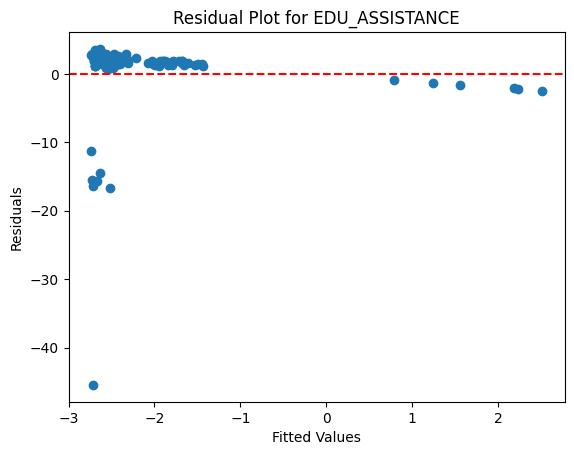

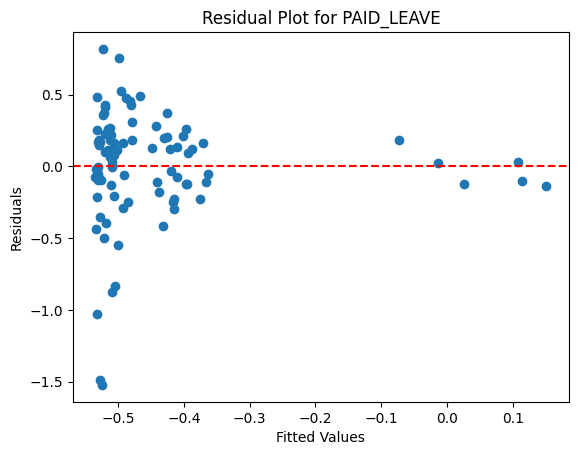

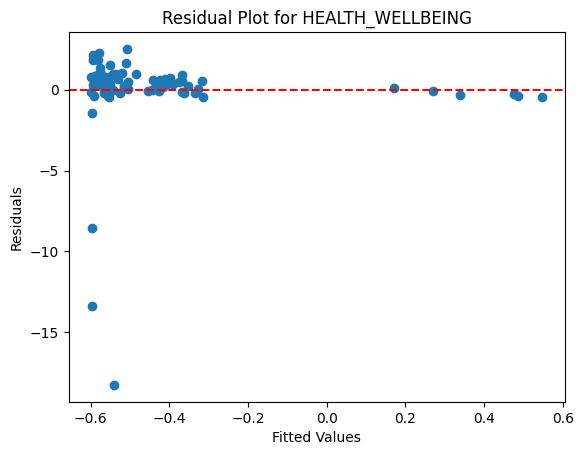

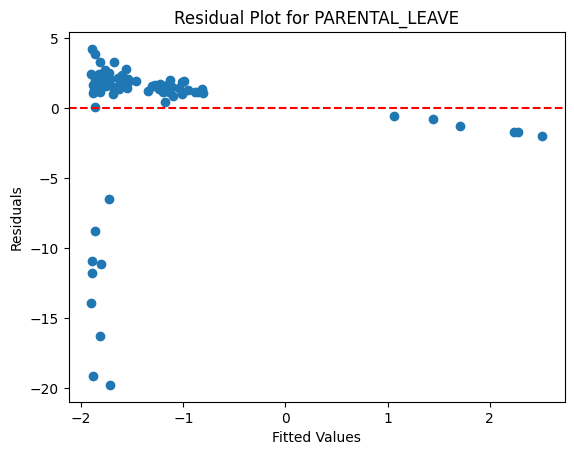

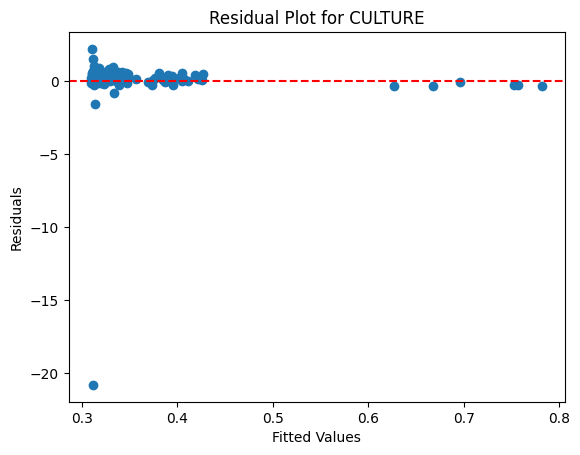

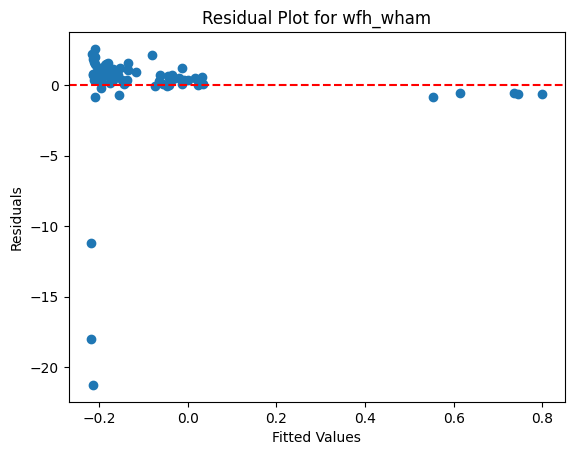

In [75]:
import matplotlib.pyplot as plt

for benefit in benefits4:
    model = benefit_models[benefit][0]  # Adjust to the model you want to test
    plt.scatter(model.fittedvalues, model.resid)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'Residual Plot for {benefit}')
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')
    plt.show()


## Multicollinearity

In [76]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

for benefit in benefits4:
    benefit_df = df_dict[benefit]
    
    # Select the independent variables for VIF calculation
    X = benefit_df[['AI Demand % Change', f'Prevalence: {benefits_labels_map[benefit]}', 'Salary (Log) Premium']]
    
    # Replace inf/-inf with NaN
    X = X.replace([np.inf, -np.inf], np.nan)
    
    # Drop rows with NaN values in any of the selected columns
    X = X.dropna()
    
    # Add a constant to the independent variables
    X = sm.add_constant(X)
    
    # Check if there is sufficient data for VIF calculation after dropping NaNs
    if X.shape[0] > 0:
        # Calculate VIF for each variable
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        print(f'VIF for {benefit}:')
        print(vif_data)
    else:
        print(f"Insufficient data for VIF calculation in {benefit} after cleaning.")


VIF for EDU_ASSISTANCE:
                          feature          VIF
0                           const  2248.688632
1              AI Demand % Change     1.046982
2  Prevalence: Tuition Assistance     1.044621
3            Salary (Log) Premium     1.032632
VIF for PAID_LEAVE:
                  feature          VIF
0                   const  2173.173121
1      AI Demand % Change     1.015220
2  Prevalence: Paid Leave     1.004706
3    Salary (Log) Premium     1.019081
VIF for HEALTH_WELLBEING:
                            feature          VIF
0                             const  2195.306593
1                AI Demand % Change     1.014831
2  Prevalence: Health and Wellbeing     1.002344
3              Salary (Log) Premium     1.016546
VIF for PARENTAL_LEAVE:
                      feature          VIF
0                       const  2186.917575
1          AI Demand % Change     1.026519
2  Prevalence: Parental Leave     1.027920
3        Salary (Log) Premium     1.027608
VIF for CULTURE:

## Autocorrelation of Errors

In [77]:
from statsmodels.stats.stattools import durbin_watson

for benefit in benefits4:
    model = benefit_models[benefit][0]  
    dw_stat = durbin_watson(model.resid)
    print(f'Durbin-Watson statistic for {benefit}: {dw_stat}')


Durbin-Watson statistic for EDU_ASSISTANCE: 1.7321609269661127
Durbin-Watson statistic for PAID_LEAVE: 1.6793345116193519
Durbin-Watson statistic for HEALTH_WELLBEING: 2.082360672427835
Durbin-Watson statistic for PARENTAL_LEAVE: 1.8583401489701352
Durbin-Watson statistic for CULTURE: 2.045116684616505
Durbin-Watson statistic for wfh_wham: 2.210555559517479


## Normality of Residuals

EDU_ASSISTANCE
Model  1


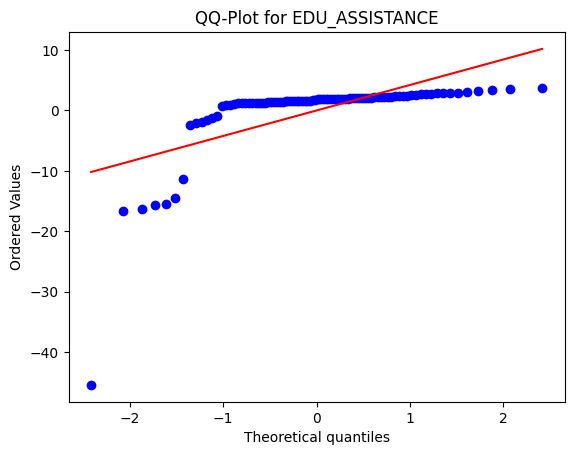

Model  2


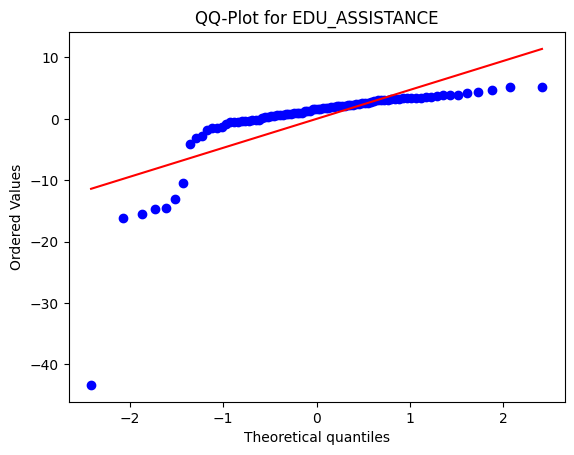

Model  3


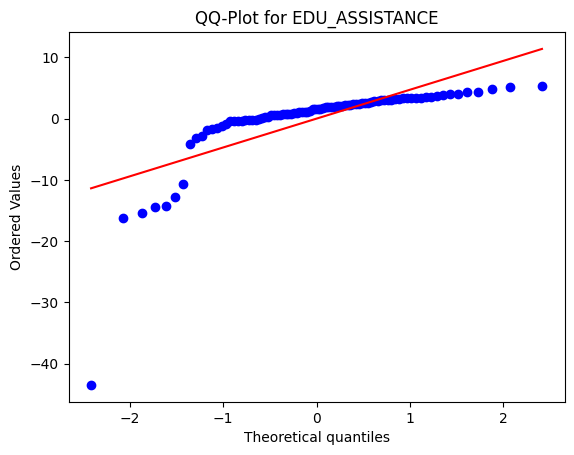

Model  4


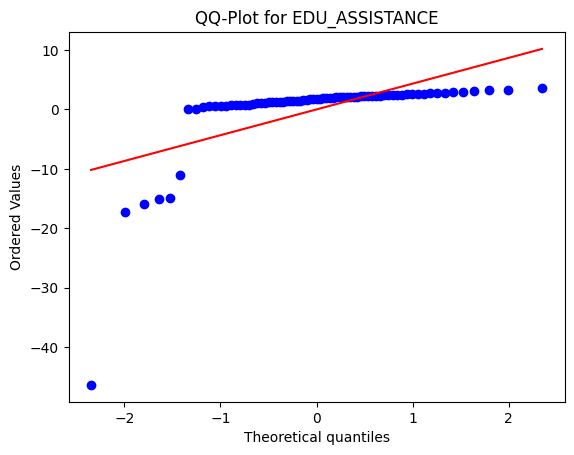

Model  5


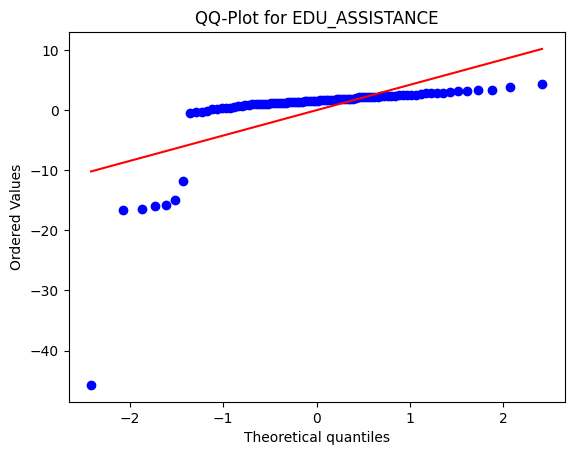

Jarque-Bera test for EDU_ASSISTANCE: JB Stat=2726.719882224052, p-value=0.0
PAID_LEAVE
Model  1


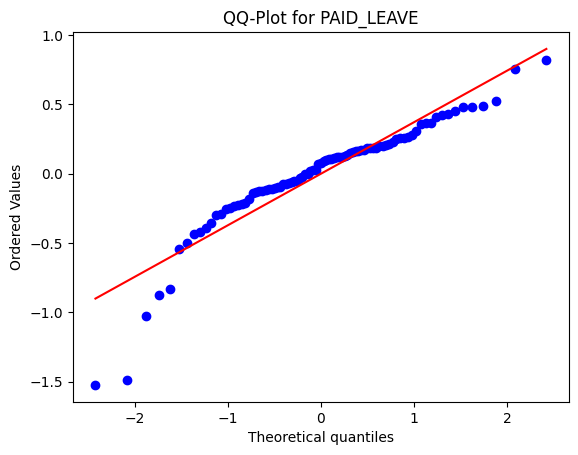

Model  2


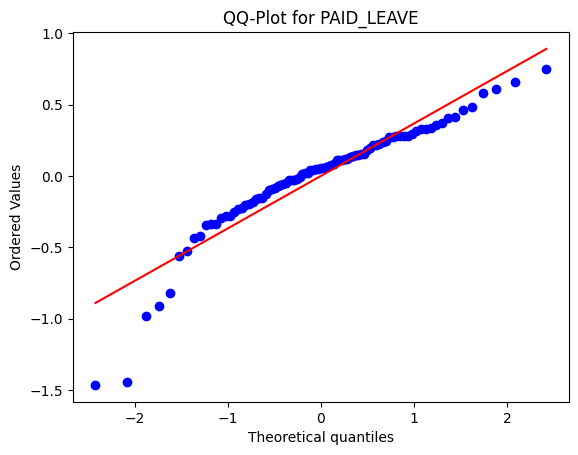

Model  3


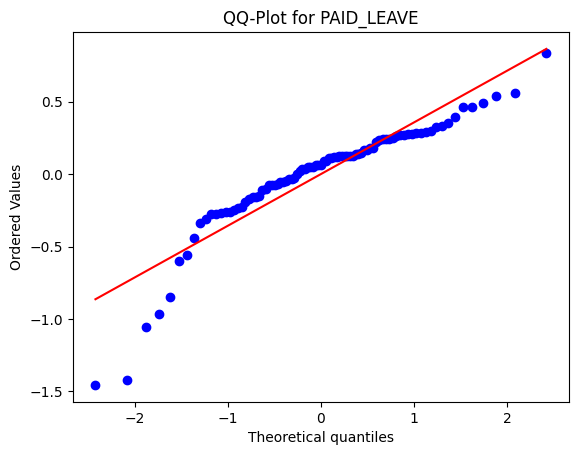

Model  4


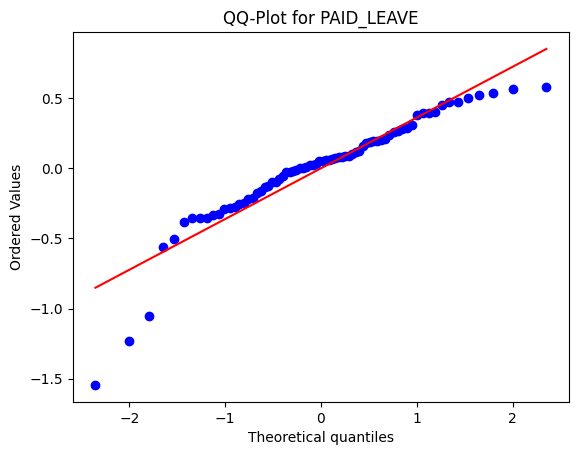

Model  5


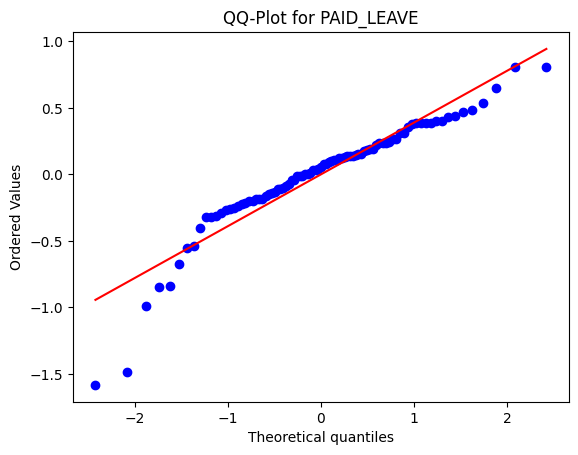

Jarque-Bera test for PAID_LEAVE: JB Stat=72.04351537329882, p-value=2.2696004465275505e-16
HEALTH_WELLBEING
Model  1


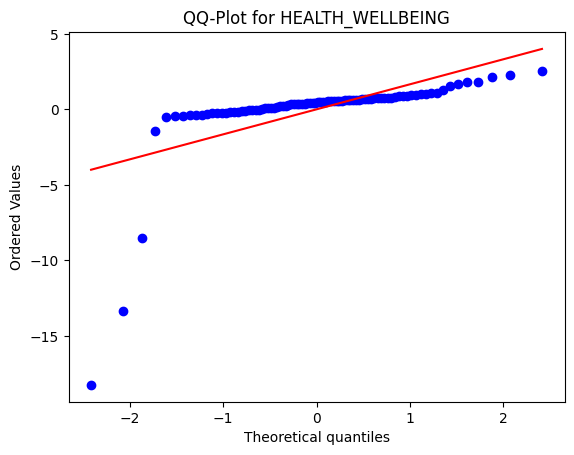

Model  2


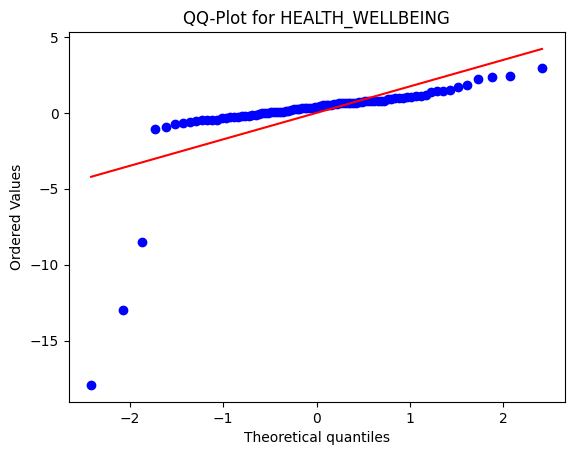

Model  3


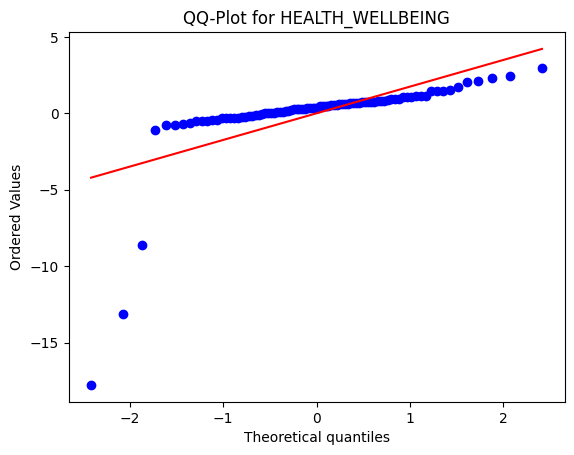

Model  4


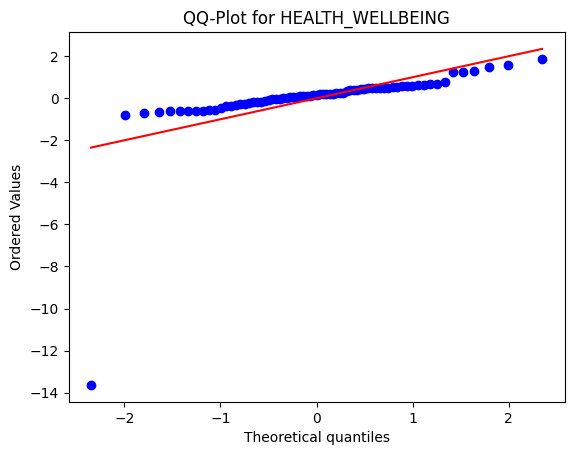

Model  5


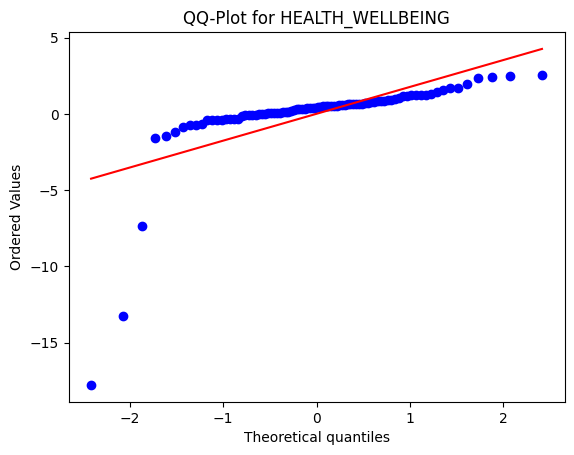

Jarque-Bera test for HEALTH_WELLBEING: JB Stat=3212.7420772156497, p-value=0.0
PARENTAL_LEAVE
Model  1


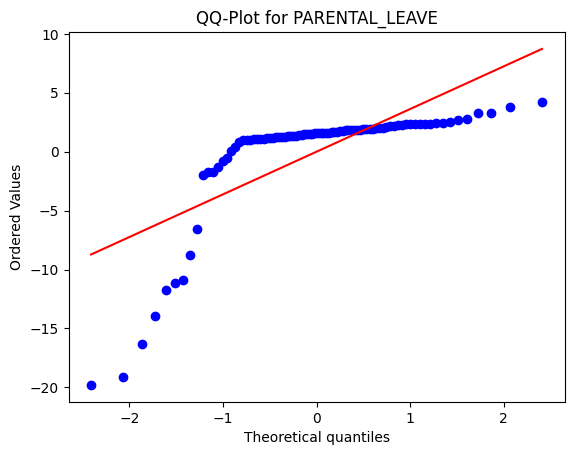

Model  2


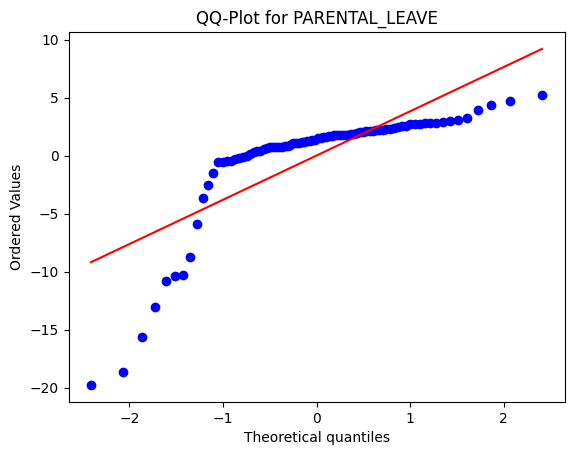

Model  3


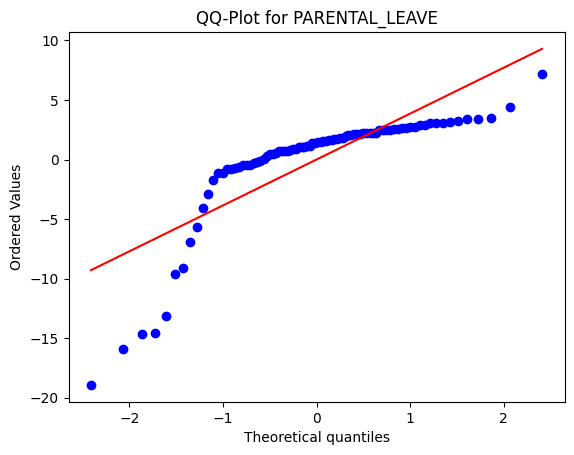

Model  4


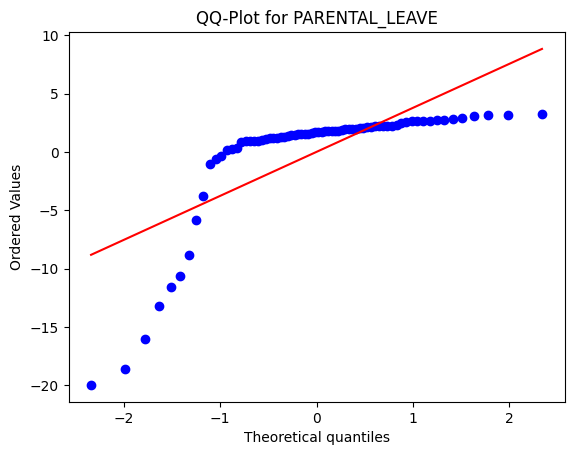

Model  5


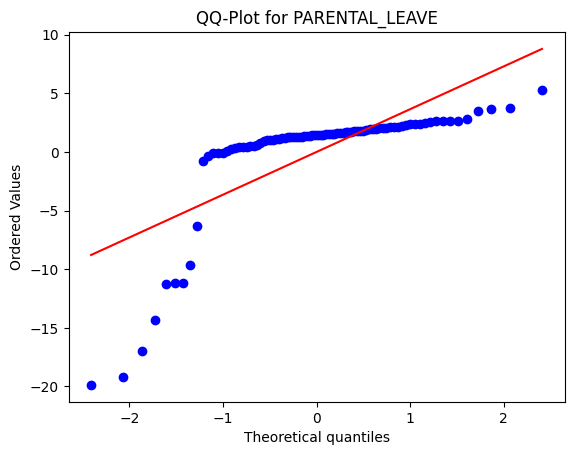

Jarque-Bera test for PARENTAL_LEAVE: JB Stat=286.08973578077536, p-value=7.523210448781018e-63
CULTURE
Model  1


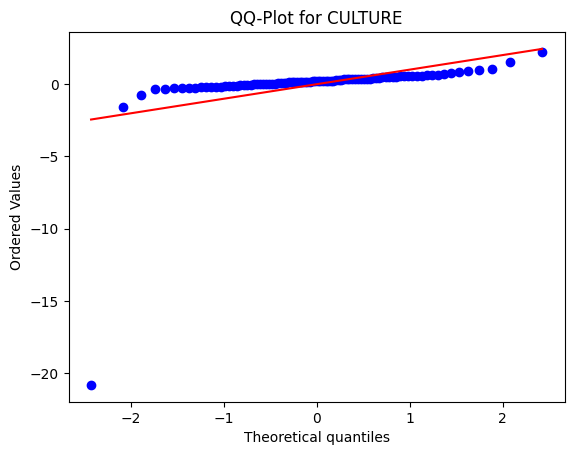

Model  2


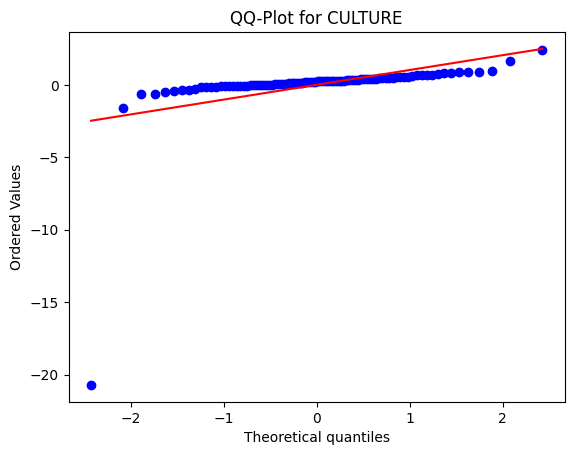

Model  3


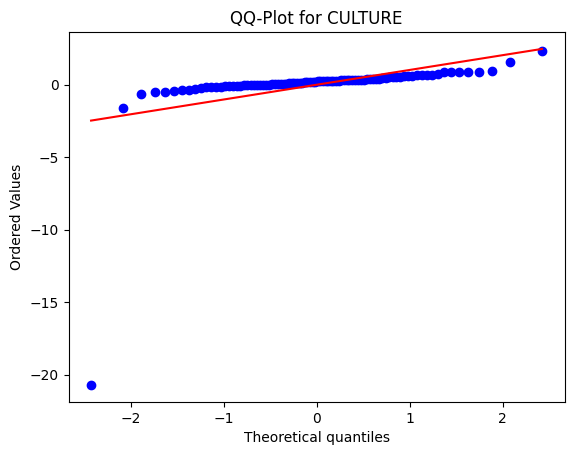

Model  4


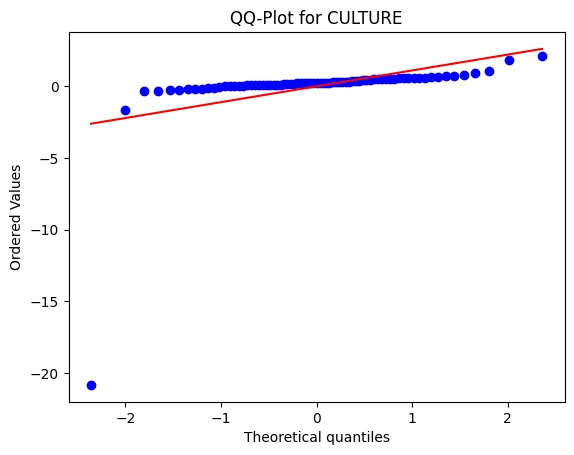

Model  5


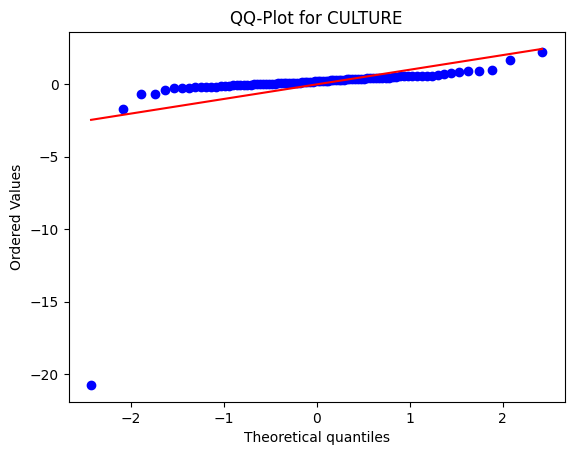

Jarque-Bera test for CULTURE: JB Stat=23847.32221682521, p-value=0.0
wfh_wham
Model  1


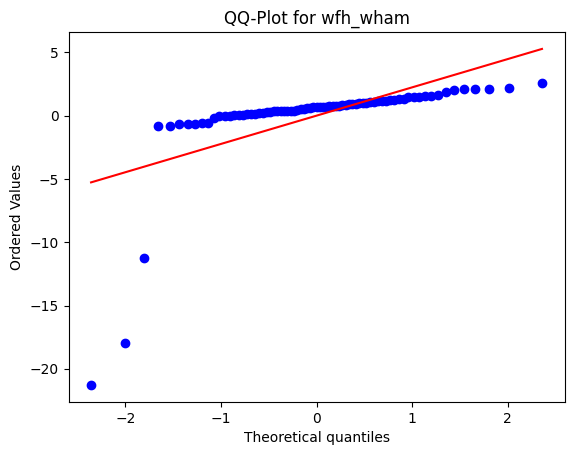

Model  2


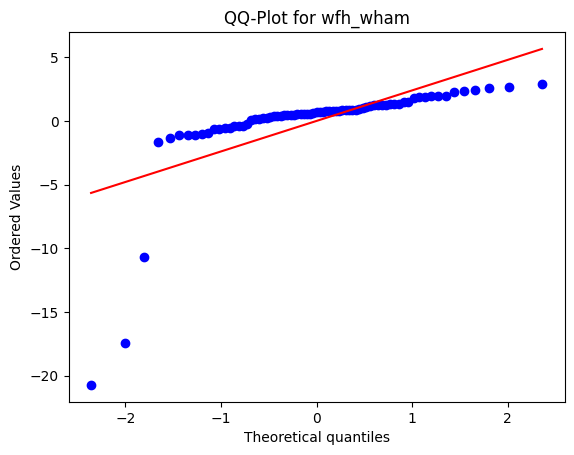

Model  3


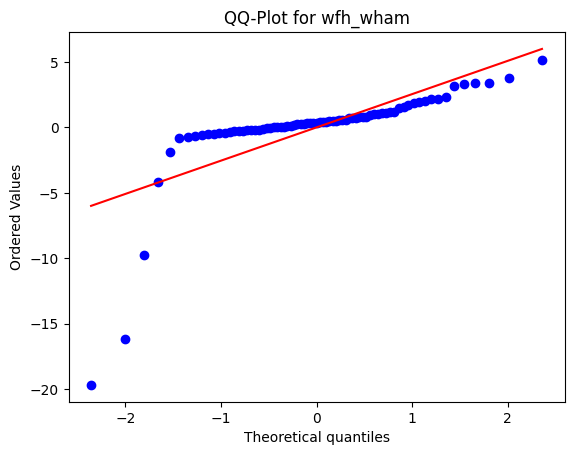

Model  4


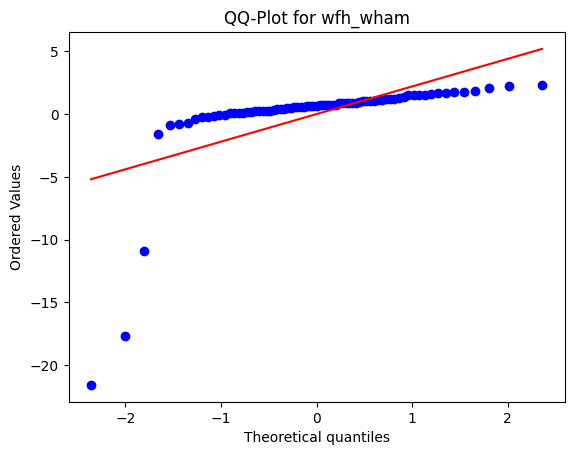

Model  5


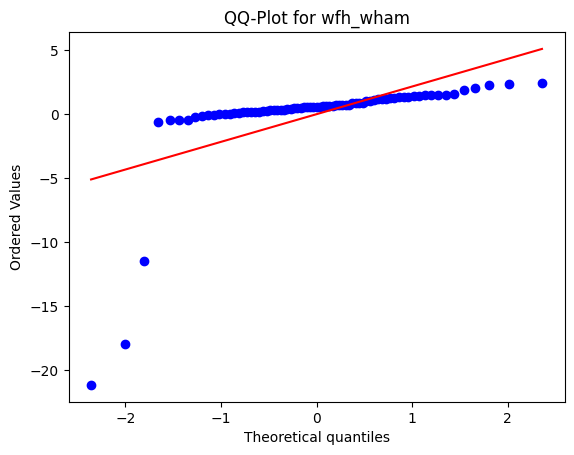

Jarque-Bera test for wfh_wham: JB Stat=1886.2515787359516, p-value=0.0


In [96]:
import scipy.stats as stats

for benefit in benefits4:
    print(benefit)
    for i in range(5):
        print("Model ", i+1)
        model = benefit_models[benefit][i]  # change for model of interest
        
        # QQ-plot
        stats.probplot(model.resid, dist="norm", plot=plt)
        plt.title(f'QQ-Plot for {benefit}')
        plt.show()
        
        # Jarque-Bera test
        jb_stat, jb_pvalue = stats.jarque_bera(model.resid)
    print(f'Jarque-Bera test for {benefit}: JB Stat={jb_stat}, p-value={jb_pvalue}')


## Homoscedasticity 

In [80]:
from statsmodels.stats.diagnostic import het_breuschpagan
for benefit in benefits4:
    print(f'Breusch-Pagan test for {benefit}:')
    for i in range(4):
        model = benefit_models[benefit][i]  # Use the relevant model
        test_result = het_breuschpagan(model.resid, model.model.exog)
        print(f'LM Statistic: {test_result[i]}, p-value: {test_result[1]}')


Breusch-Pagan test for EDU_ASSISTANCE:
LM Statistic: 0.9156223166715387, p-value: 0.3386270404029053
LM Statistic: 0.10579030092157568, p-value: 0.10579030092157568
LM Statistic: 2.07669184731486, p-value: 0.10796609046722232
LM Statistic: 0.8881975376198995, p-value: 0.8862550935553652
Breusch-Pagan test for PAID_LEAVE:
LM Statistic: 2.565142601091223, p-value: 0.10924270641252731
LM Statistic: 0.183740923551518, p-value: 0.183740923551518
LM Statistic: 1.275154120159774, p-value: 0.2800733300685627
LM Statistic: 0.32219634697179056, p-value: 0.3155447345561434
Breusch-Pagan test for HEALTH_WELLBEING:
LM Statistic: 0.6030659394297588, p-value: 0.43741061656136804
LM Statistic: 0.23925941476822396, p-value: 0.23925941476822396
LM Statistic: 1.2489152663075995, p-value: 0.28886140015015055
LM Statistic: 0.43418231245684613, p-value: 0.4271572919386756
Breusch-Pagan test for PARENTAL_LEAVE:
LM Statistic: 2.3111038433803532, p-value: 0.12845280068556306
LM Statistic: 0.08889630055486754, 

# Outliers

In [100]:
for benefit in benefits4:
    print(benefit)
    benefit_df = df_dict[benefit]
    # Check for outliers in the 'AI Coefficient' column using the IQR method
    Q1 = benefit_df['AI Coefficient'].quantile(0.25)
    Q3 = benefit_df['AI Coefficient'].quantile(0.75)
    IQR = Q3 - Q1

    # Define the bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers
    outliers = benefit_df[(benefit_df['AI Coefficient'] < lower_bound) | (benefit_df['AI Coefficient'] > upper_bound)]
    display(outliers)



EDU_ASSISTANCE


,Benefit,Occupation,Year,AI Coefficient,Error,P-Value,SOC_2021_2_NAME,YEAR,AI Demand,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,DURATION_CALC_ai,DURATION_CALC_non_ai,MEAN SALARY,job_count,Prevalence: Tuition Assistance,Prevalence: Paid Leave,Prevalence: Health and Wellbeing,Prevalence: Parental Leave,Prevalence: Workplace Culture,Prevalence: Remote Work
18,EDU_ASSISTANCE,Community and Social Service Occupations,2019,-17.088970,2.526274e+03,0.995,Community and Social Service Occupations,2019,0.209644,5.685535,NaN,11.261758,85801.000000,10.791859,54060.824612,104.354200,158.711970,52.984375,60.192161,54082.449668,30528,6.426887,18.740173,3.920991,2.803983,5.087133,4.690753
21,EDU_ASSISTANCE,Community and Social Service Occupations,2020,-18.268931,4.897209e+03,0.997,Community and Social Service Occupations,2020,0.151799,-27.591887,5.685535,10.888461,62235.166667,10.778845,53002.275233,101.016949,117.419802,61.000000,61.015009,53010.348295,30962,7.451069,24.869194,3.898327,3.627027,6.084878,8.896913
45,EDU_ASSISTANCE,Legal Occupations,2020,-19.117916,1.240589e+04,0.999,Legal Occupations,2020,0.444576,-28.477125,18.425080,12.323856,225000.000000,10.935397,64843.026643,112.696921,346.991823,61.200000,60.234395,64899.900568,10122,2.499506,23.443983,2.282158,2.618060,5.265758,15.307540
66,EDU_ASSISTANCE,Personal Care and Service Occupations,2019,-48.173292,4.490231e+10,1.000,Personal Care and Service Occupations,2019,0.061836,20.950725,NaN,10.349295,32576.666667,10.409556,36016.100200,99.421094,90.450289,61.250000,62.476817,36012.657324,25875,2.291787,9.236715,1.913043,0.668599,3.934300,0.896897
67,EDU_ASSISTANCE,Personal Care and Service Occupations,2021,-19.057773,1.535807e+04,0.999,Personal Care and Service Occupations,2021,0.069618,22.598162,-8.166525,10.772009,56361.625000,10.535373,41693.669480,102.246115,135.180294,62.650000,66.127003,41706.863054,28728,4.619187,20.182400,2.342662,1.489836,5.092593,1.648662
70,EDU_ASSISTANCE,Personal Care and Service Occupations,2018,-18.225274,1.690783e+04,0.999,Personal Care and Service Occupations,2018,0.051125,NaN,NaN,11.682838,118574.000000,10.367422,34633.501841,112.687977,342.367920,67.230769,65.461184,34677.634595,25428,1.569136,6.142835,1.592732,0.318546,3.401762,0.000000
84,EDU_ASSISTANCE,Transportation and Material Moving Occupations,2019,-14.053173,8.263250e+02,0.986,Transportation and Material Moving Occupations,2019,0.033652,-18.600785,NaN,10.485831,38192.625000,10.591160,44183.609987,99.005500,86.440707,59.806452,61.214999,44182.104241,92120,4.829570,21.079027,3.222970,0.578593,2.248155,0.385060


PAID_LEAVE


,Benefit,Occupation,Year,AI Coefficient,Error,P-Value,SOC_2021_2_NAME,YEAR,AI Demand,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,DURATION_CALC_ai,DURATION_CALC_non_ai,MEAN SALARY,job_count,Prevalence: Tuition Assistance,Prevalence: Paid Leave,Prevalence: Health and Wellbeing,Prevalence: Parental Leave,Prevalence: Workplace Culture,Prevalence: Remote Work
199,PAID_LEAVE,Community and Social Service Occupations,2021,-2.047150,0.516496,0.000,Community and Social Service Occupations,2021,0.172751,13.802518,-27.591887,11.172405,83638.384615,10.836224,55792.444588,103.102384,149.909876,65.470588,67.446494,55825.698053,39363,9.646114,32.149480,5.350202,4.605848,10.824886,11.355638
214,PAID_LEAVE,Educational Instruction and Library Occupations,2018,-1.384205,0.586692,0.018,Educational Instruction and Library Occupations,2018,0.388070,NaN,NaN,10.963601,61413.142857,10.692107,49305.180216,102.539199,124.557182,64.518519,63.682947,49316.319096,41745,4.498742,7.988981,3.195592,0.483890,5.933645,0.000000
225,PAID_LEAVE,Legal Occupations,2020,-1.336675,0.600917,0.026,Legal Occupations,2020,0.444576,-28.477125,18.425080,12.323856,225000.000000,10.935397,64843.026643,112.696921,346.991823,61.200000,60.234395,64899.900568,10122,2.499506,23.443983,2.282158,2.618060,5.265758,15.307540
248,PAID_LEAVE,Personal Care and Service Occupations,2022,-2.013768,0.730128,0.006,Personal Care and Service Occupations,2022,0.117110,68.217456,22.598162,10.729980,48542.266667,10.608435,44149.221960,101.145735,109.950446,57.842105,57.464702,44154.582818,32448,5.186760,24.932199,3.186637,1.969305,6.234591,3.028801
265,PAID_LEAVE,Transportation and Material Moving Occupations,2021,-1.557926,0.296125,0.000,Transportation and Material Moving Occupations,2021,0.067199,149.616383,-20.001353,10.663532,48247.636364,10.664556,46919.891740,99.990403,102.829812,66.026549,65.484129,46920.261844,168157,7.579227,36.863764,7.994910,3.968315,5.318839,0.769559


HEALTH_WELLBEING


...

,Benefit,Occupation,Year,AI Coefficient,Error,P-Value,SOC_2021_2_NAME,YEAR,AI Demand,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,DURATION_CALC_ai,DURATION_CALC_non_ai,MEAN SALARY,job_count,Prevalence: Tuition Assistance,Prevalence: Paid Leave,Prevalence: Health and Wellbeing,Prevalence: Parental Leave,Prevalence: Workplace Culture,Prevalence: Remote Work
393,PARENTAL_LEAVE,Educational Instruction and Library Occupations,2020,-8.241611,49.035642,0.867,Educational Instruction and Library Occupations,2020,0.422228,-13.933355,26.415860,10.997901,65152.200000,10.630072,46730.732960,103.460264,139.420454,63.405556,62.439566,46756.461266,42631,7.250592,16.312073,3.706223,1.238535,7.008984,5.752181
397,PARENTAL_LEAVE,Healthcare Practitioners and Technical Occupat...,2021,-1.788601,1.002713,0.074,Healthcare Practitioners and Technical Occupat...,2021,0.118650,30.420294,-14.448122,11.303001,104441.276596,11.277126,93280.540869,100.229442,111.964699,65.286738,68.125548,93293.661622,235145,11.758702,23.441706,3.634353,2.129324,9.094814,3.068050
400,PARENTAL_LEAVE,Healthcare Practitioners and Technical Occupat...,2018,1.969853,0.423434,0.000,Healthcare Practitioners and Technical Occupat...,2018,0.112572,NaN,NaN,10.989714,71206.733333,11.151441,80040.810800,98.549723,88.963034,62.676617,65.211347,80033.339911,178552,5.241050,9.687374,1.899727,0.457010,2.537636,3.658537
405,PARENTAL_LEAVE,Legal Occupations,2020,-21.504651,40597.910610,1.000,Legal Occupations,2020,0.444576,-28.477125,18.425080,12.323856,225000.000000,10.935397,64843.026643,112.696921,346.991823,61.200000,60.234395,64899.900568,10122,2.499506,23.443983,2.282158,2.618060,5.265758,15.307540
427,PARENTAL_LEAVE,Personal Care and Service Occupations,2021,-21.027104,69392.873376,1.000,Personal Care and Service Occupations,2021,0.069618,22.598162,-8.166525,10.772009,56361.625000,10.535373,41693.669480,102.246115,135.180294,62.650000,66.127003,41706.863054,28728,4.619187,20.182400,2.342662,1.489836,5.092593,1.648662
429,PARENTAL_LEAVE,Personal Care and Service Occupations,2020,-12.811815,1421.558281,0.993,Personal Care and Service Occupations,2020,0.056786,-8.166525,20.950725,9.981969,21840.000000,10.415643,36208.732742,95.836320,60.316941,61.285714,61.625771,36203.109705,24654,3.309808,13.969336,2.052405,1.216841,3.581569,2.163225
430,PARENTAL_LEAVE,Personal Care and Service Occupations,2018,-13.655633,3971.575045,0.997,Personal Care and Service Occupations,2018,0.051125,NaN,NaN,11.682838,118574.000000,10.367422,34633.501841,112.687977,342.367920,67.230769,65.461184,34677.634595,25428,1.569136,6.142835,1.592732,0.318546,3.401762,0.000000
431,PARENTAL_LEAVE,Personal Care and Service Occupations,2023,-10.626688,189.745173,0.955,Personal Care and Service Occupations,2023,0.121080,3.389200,68.217456,10.875849,57507.150000,10.655758,46148.414794,102.065463,124.613489,55.806452,50.906695,46166.810997,25603,6.405499,28.781783,3.991720,2.550482,7.362418,2.141648
432,PARENTAL_LEAVE,Production Occupations,2019,-12.972775,680.086566,0.985,Production Occupations,2019,0.240553,13.306832,NaN,10.937930,63100.350000,10.453021,37275.458164,104.638936,169.281219,62.787402,59.601713,37312.853026,52795,4.409508,14.353632,2.880955,0.598542,3.422673,1.084949
435,PARENTAL_LEAVE,Production Occupations,2020,-18.144972,6097.057469,0.998,Production Occupations,2020,0.223379,-7.139315,13.306832,11.003803,74236.000000,10.448689,36500.610922,105.312760,203.382897,57.330827,60.053664,36542.230836,59540,5.969096,21.560296,3.558952,0.972455,3.317098,1.916209


CULTURE


,Benefit,Occupation,Year,AI Coefficient,Error,P-Value,SOC_2021_2_NAME,YEAR,AI Demand,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,DURATION_CALC_ai,DURATION_CALC_non_ai,MEAN SALARY,job_count,Prevalence: Tuition Assistance,Prevalence: Paid Leave,Prevalence: Health and Wellbeing,Prevalence: Parental Leave,Prevalence: Workplace Culture,Prevalence: Remote Work
496,CULTURE,Legal Occupations,2018,-0.433602,0.730634,0.553,Legal Occupations,2018,0.524877,NaN,NaN,12.206073,200000.000000,10.987897,68150.145684,111.086524,293.469659,64.479167,61.249643,68222.590659,9145,2.110443,8.769820,2.165118,1.049754,4.319300,0.000000
517,CULTURE,Personal Care and Service Occupations,2021,-20.496101,24387.479680,0.999,Personal Care and Service Occupations,2021,0.069618,22.598162,-8.166525,10.772009,56361.625000,10.535373,41693.669480,102.246115,135.180294,62.650000,66.127003,41706.863054,28728,4.619187,20.182400,2.342662,1.489836,5.092593,1.648662
519,CULTURE,Personal Care and Service Occupations,2020,2.542858,0.597436,0.000,Personal Care and Service Occupations,2020,0.056786,-8.166525,20.950725,9.981969,21840.000000,10.415643,36208.732742,95.836320,60.316941,61.285714,61.625771,36203.109705,24654,3.309808,13.969336,2.052405,1.216841,3.581569,2.163225
521,CULTURE,Personal Care and Service Occupations,2023,-1.263840,1.025905,0.218,Personal Care and Service Occupations,2023,0.121080,3.389200,68.217456,10.875849,57507.150000,10.655758,46148.414794,102.065463,124.613489,55.806452,50.906695,46166.810997,25603,6.405499,28.781783,3.991720,2.550482,7.362418,2.141648
535,CULTURE,Transportation and Material Moving Occupations,2021,1.845892,0.207550,0.000,Transportation and Material Moving Occupations,2021,0.067199,149.616383,-20.001353,10.663532,48247.636364,10.664556,46919.891740,99.990403,102.829812,66.026549,65.484129,46920.261844,168157,7.579227,36.863764,7.994910,3.968315,5.318839,0.769559


wfh_wham


,Benefit,Occupation,Year,AI Coefficient,Error,P-Value,SOC_2021_2_NAME,YEAR,AI Demand,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,DURATION_CALC_ai,DURATION_CALC_non_ai,MEAN SALARY,job_count,Prevalence: Tuition Assistance,Prevalence: Paid Leave,Prevalence: Health and Wellbeing,Prevalence: Parental Leave,Prevalence: Workplace Culture,Prevalence: Remote Work
595,wfh_wham,Personal Care and Service Occupations,2019,-21.489200,71519.829654,1.000,Personal Care and Service Occupations,2019,0.061836,20.950725,NaN,10.349295,32576.666667,10.409556,36016.100200,99.421094,90.450289,61.250000,62.476817,36012.657324,25875,2.291787,9.236715,1.913043,0.668599,3.934300,0.896897
597,wfh_wham,Personal Care and Service Occupations,2022,2.369752,0.396736,0.000,Personal Care and Service Occupations,2022,0.117110,68.217456,22.598162,10.729980,48542.266667,10.608435,44149.221960,101.145735,109.950446,57.842105,57.464702,44154.582818,32448,5.186760,24.932199,3.186637,1.969305,6.234591,3.028801
610,wfh_wham,Transportation and Material Moving Occupations,2019,-18.205488,17234.764550,0.999,Transportation and Material Moving Occupations,2019,0.033652,-18.600785,NaN,10.485831,38192.625000,10.591160,44183.609987,99.005500,86.440707,59.806452,61.214999,44182.104241,92120,4.829570,21.079027,3.222970,0.578593,2.248155,0.385060
613,wfh_wham,Transportation and Material Moving Occupations,2020,-11.442227,437.577258,0.979,Transportation and Material Moving Occupations,2020,0.026921,-20.001353,-18.600785,10.529685,40678.900000,10.562795,42269.527535,99.686540,96.236940,55.210526,62.520019,42269.295590,141154,5.673945,29.072502,7.670346,1.370135,2.021905,0.565415


In [98]:
outliers

,Benefit,Occupation,Year,AI Coefficient,Error,P-Value,SOC_2021_2_NAME,YEAR,AI Demand,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,DURATION_CALC_ai,DURATION_CALC_non_ai,MEAN SALARY,job_count,Prevalence: Tuition Assistance,Prevalence: Paid Leave,Prevalence: Health and Wellbeing,Prevalence: Parental Leave,Prevalence: Workplace Culture,Prevalence: Remote Work
18,EDU_ASSISTANCE,Community and Social Service Occupations,2019,-17.088970,2.526274e+03,0.995,Community and Social Service Occupations,2019,0.209644,5.685535,NaN,11.261758,85801.000000,10.791859,54060.824612,104.354200,158.711970,52.984375,60.192161,54082.449668,30528,6.426887,18.740173,3.920991,2.803983,5.087133,4.690753
21,EDU_ASSISTANCE,Community and Social Service Occupations,2020,-18.268931,4.897209e+03,0.997,Community and Social Service Occupations,2020,0.151799,-27.591887,5.685535,10.888461,62235.166667,10.778845,53002.275233,101.016949,117.419802,61.000000,61.015009,53010.348295,30962,7.451069,24.869194,3.898327,3.627027,6.084878,8.896913
34,EDU_ASSISTANCE,Educational Instruction and Library Occupations,2018,-1.886071,1.009148e+00,0.062,Educational Instruction and Library Occupations,2018,0.388070,NaN,NaN,10.963601,61413.142857,10.692107,49305.180216,102.539199,124.557182,64.518519,63.682947,49316.319096,41745,4.498742,7.988981,3.195592,0.483890,5.933645,0.000000
45,EDU_ASSISTANCE,Legal Occupations,2020,-19.117916,1.240589e+04,0.999,Legal Occupations,2020,0.444576,-28.477125,18.425080,12.323856,225000.000000,10.935397,64843.026643,112.696921,346.991823,61.200000,60.234395,64899.900568,10122,2.499506,23.443983,2.282158,2.618060,5.265758,15.307540
66,EDU_ASSISTANCE,Personal Care and Service Occupations,2019,-48.173292,4.490231e+10,1.000,Personal Care and Service Occupations,2019,0.061836,20.950725,NaN,10.349295,32576.666667,10.409556,36016.100200,99.421094,90.450289,61.250000,62.476817,36012.657324,25875,2.291787,9.236715,1.913043,0.668599,3.934300,0.896897
67,EDU_ASSISTANCE,Personal Care and Service Occupations,2021,-19.057773,1.535807e+04,0.999,Personal Care and Service Occupations,2021,0.069618,22.598162,-8.166525,10.772009,56361.625000,10.535373,41693.669480,102.246115,135.180294,62.650000,66.127003,41706.863054,28728,4.619187,20.182400,2.342662,1.489836,5.092593,1.648662
70,EDU_ASSISTANCE,Personal Care and Service Occupations,2018,-18.225274,1.690783e+04,0.999,Personal Care and Service Occupations,2018,0.051125,NaN,NaN,11.682838,118574.000000,10.367422,34633.501841,112.687977,342.367920,67.230769,65.461184,34677.634595,25428,1.569136,6.142835,1.592732,0.318546,3.401762,0.000000
84,EDU_ASSISTANCE,Transportation and Material Moving Occupations,2019,-14.053173,8.263250e+02,0.986,Transportation and Material Moving Occupations,2019,0.033652,-18.600785,NaN,10.485831,38192.625000,10.591160,44183.609987,99.005500,86.440707,59.806452,61.214999,44182.104241,92120,4.829570,21.079027,3.222970,0.578593,2.248155,0.385060
158,WLB,Personal Care and Service Occupations,2022,-2.089877,7.293603e-01,0.004,Personal Care and Service Occupations,2022,0.117110,68.217456,22.598162,10.729980,48542.266667,10.608435,44149.221960,101.145735,109.950446,57.842105,57.464702,44154.582818,32448,5.186760,24.932199,3.186637,1.969305,6.234591,3.028801
199,PAID_LEAVE,Community and Social Service Occupations,2021,-2.047150,5.164964e-01,0.000,Community and Social Service Occupations,2021,0.172751,13.802518,-27.591887,11.172405,83638.384615,10.836224,55792.444588,103.102384,149.909876,65.470588,67.446494,55825.698053,39363,9.646114,32.149480,5.350202,4.605848,10.824886,11.355638


# Correlations

In [65]:
df_single = df[df['Benefit'] == 'EDU_ASSISTANCE']

In [70]:
# select all columns beginning with Prevalence: 
prevalence_cols = [col for col in df_single.columns if col.startswith('Prevalence: ')]
df_prevalence = df_single[prevalence_cols + ['MEAN SALARY']]

In [71]:
correlation_matrix = df_prevalence.corr()

In [72]:
correlation_matrix

,Prevalence: Tuition Assistance,Prevalence: Paid Leave,Prevalence: Health and Wellbeing,Prevalence: Parental Leave,Prevalence: Workplace Culture,Prevalence: Remote Work,MEAN SALARY
Prevalence: Tuition Assistance,1.000000,0.728160,0.747710,0.710566,0.681205,0.198934,0.302153
Prevalence: Paid Leave,0.728160,1.000000,0.821199,0.826273,0.588488,0.332908,0.061352
Prevalence: Health and Wellbeing,0.747710,0.821199,1.000000,0.799309,0.665764,0.361631,0.170931
Prevalence: Parental Leave,0.710566,0.826273,0.799309,1.000000,0.840941,0.615655,0.364900
Prevalence: Workplace Culture,0.681205,0.588488,0.665764,0.840941,1.000000,0.720926,0.541894
Prevalence: Remote Work,0.198934,0.332908,0.361631,0.615655,0.720926,1.000000,0.593625
MEAN SALARY,0.302153,0.061352,0.170931,0.364900,0.541894,0.593625,1.000000


Text(0.5, -0.15, 'Correlation Matrix of Benefits Prevalence on Occupation-Year Level')

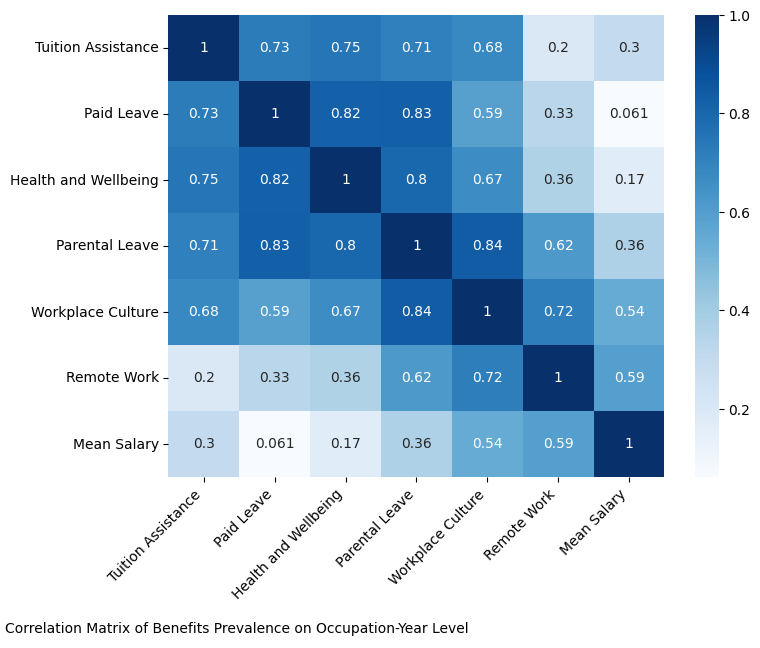

In [74]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', cbar = True)
plt.xticks(ticks=np.arange(len(correlation_matrix.columns))+0.5, labels=benefits4_labels + ['Mean Salary'], rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(correlation_matrix.columns))+0.5, labels=benefits4_labels + ['Mean Salary'], rotation=0, va='center')
plt.figtext(0.5, -0.15, 'Correlation Matrix of Benefits Prevalence on Occupation-Year Level', wrap=True, horizontalalignment='right', fontsize=10)